**LangChains Expression Language**

In this example, we will introduce LangChain's Expression Langauge (LCEL), abstracting a full chain and understanding how it will work.

In [2]:
!pip install -qU \
    docarray


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import langchain_core
import langchain_community
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1",
    temperature=0
)

c:\Users\PatelDharmikkumar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Traditional Chains vs LCEL
In this section we're going to dive into a basic example using the traditional method for building chains before jumping into LCEL. We will build a pipeline where the user must input a specific topic, and then the LLM will look and return a report on the specified topic. Generating a research report for the user.

**Traditional LLMChain**

The LLMChain is the simplest chain originally introduced in LangChain. This chain takes a prompt, feeds it into an LLM, and optionally adds an output parsing step before returning the result.

Let's see how we construct this using the traditional method, for this we need:

+ prompt — a PromptTemplate that will be used to generate the prompt for the LLM.
+ llm — the LLM we will be using to generate the output.
+ output_parser — an optional output parser that will be used to parse the structured output of the LLM.

**Report on Retrieval-Augmented Generation (RAG)**

**Introduction**

Retrieval-Augmented Generation (RAG) is an advanced approach in natural language processing (NLP) that combines the strengths of information retrieval and generative models. This technique enhances the capabilities of language models by allowing them to access external knowledge bases or documents during the generation process, thereby improving the relevance and accuracy of the generated content.

Key Components

+ Retrieval Mechanism: RAG employs a retrieval system to fetch relevant documents or pieces of information from a large corpus based on the input query. This is typically done using techniques such as vector embeddings or traditional keyword matching.

+ Generative Model: After retrieving relevant information, a generative model (often based on transformer architectures like BERT or GPT) processes this information along with the original query to produce coherent and contextually appropriate responses

+ Integration: The integration of retrieval and generation can occur in various ways, such as:
    + End-to-End Training: The retrieval and generation components are trained together, allowing the model to learn how to select the most relevant documents for generating responses.
    + Pipeline Approach: The retrieval and generation processes are handled separately, where the output of the retrieval phase serves as input to the generative model.


+ Advantages
    + Enhanced Knowledge Access: RAG allows models to leverage vast amounts of external knowledge, making them more informed and capable of providing accurate answers.
    + Improved Contextuality: By retrieving relevant documents, the generative model can produce responses that are more contextually relevant and factually accurate.
    + Scalability: RAG systems can scale to incorporate new information without the need for retraining the entire model, as the retrieval component can be updated independently.

+ Applications
    + Question Answering: RAG is particularly effective in question-answering systems where users seek specific information from a large knowledge base.
    + Chatbots and Virtual Assistants: By integrating RAG, chatbots can provide more accurate and contextually relevant responses to user queries.
    + Content Generation: RAG can be used in content creation tools to generate articles or reports that are well-informed and factually accurate.

+ Challenges
    + Complexity: The integration of retrieval and generation components can introduce complexity in model training and deployment.
    + Latency: The retrieval process may add latency to response times, which can be a concern in real-time applications.
    + Quality of Retrieved Information: The effectiveness of RAG heavily depends on the quality and relevance of the retrieved documents. Poor retrieval can lead to inaccurate or irrelevant generated content.

**Conclusion**

Retrieval-Augmented Generation represents a significant advancement in the field of NLP, combining the strengths of retrieval systems and generative models to produce more accurate and contextually relevant outputs. As research and development in this area continue, RAG is likely to play a crucial role in enhancing various applications, from chatbots to content generation tools, while also addressing the challenges associated with its implementation.

********LangChain Expression Language (LCEL)********

LangChain Expression Language (LCEL) is the recommended approach to building chains in LangChain. Having superceeded the traditional methods with LLMChain, etc. LCEL gives us a more flexible system for building chains. The pipe operator | is used by LCEL to chain together components. Let's see how we'd construct an LLMChain using LCEL.

In [9]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
prompt_template = "Give me a small report on {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_template
)
output_parser = StrOutputParser()
lcel_chain = prompt | llm | output_parser
result = lcel_chain.invoke("retrieval augmented generation")
result

"Here's a small report on Retrieval-Augmented Generation (RAG):\n\n**What is Retrieval-Augmented Generation (RAG)?**\n\nRetrieval-Augmented Generation (RAG) is a type of artificial intelligence model that combines the strengths of two different approaches: retrieval-based models and generative models. The goal of RAG is to leverage the benefits of both worlds by using a retrieval component to gather relevant information from a large database, which is then used as input to a generative model.\n\n**How does RAG work?**\n\nThe process of RAG can be broken down into three main steps:\n\n1. **Retrieval**: A retrieval module searches through a large database (e.g., a knowledge graph or a text corpus) to find relevant information related to the input query.\n2. **Augmentation**: The retrieved information is then used as input to a generative model, which generates new content based on this augmented input.\n3. **Generation**: The final output of the RAG system is generated by the generative 

The output format is slightly different, but the underlying functionality and content being output is the same. As before, we can view a formatted version of this output using the Markdown display:

In [19]:
from IPython.display import Markdown

# Just evaluate the object on the last line
Markdown(result)

Here's a small report on Retrieval-Augmented Generation (RAG):

**What is Retrieval-Augmented Generation (RAG)?**

Retrieval-Augmented Generation (RAG) is a type of artificial intelligence model that combines the strengths of two different approaches: retrieval-based models and generative models. The goal of RAG is to leverage the benefits of both worlds by using a retrieval component to gather relevant information from a large database, which is then used as input to a generative model.

**How does RAG work?**

The process of RAG can be broken down into three main steps:

1. **Retrieval**: A retrieval module searches through a large database (e.g., a knowledge graph or a text corpus) to find relevant information related to the input query.
2. **Augmentation**: The retrieved information is then used as input to a generative model, which generates new content based on this augmented input.
3. **Generation**: The final output of the RAG system is generated by the generative model, taking into account both the original input and the retrieved information.

**Key benefits of RAG**

RAG has several key benefits:

1. **Improved accuracy**: By leveraging external knowledge from a large database, RAG can generate more accurate and informative outputs.
2. **Increased efficiency**: RAG can reduce the need for extensive training data, as it relies on pre-existing knowledge in the database.
3. **Flexibility**: RAG can be applied to various tasks, such as question answering, text summarization, and conversational dialogue.

**Applications of RAG**

RAG has several potential applications:

1. **Question answering**: RAG can be used to answer complex questions by retrieving relevant information from a knowledge graph.
2. **Text summarization**: RAG can generate summaries of long documents by retrieving key points and generating new content based on this information.
3. **Conversational dialogue**: RAG can be used in conversational AI systems, where it retrieves relevant context and generates responses accordingly.

**Challenges and limitations**

While RAG has shown promising results, there are still several challenges and limitations to consider:

1. **Retrieval efficiency**: The retrieval component must be efficient enough to retrieve relevant information quickly.
2. **Data quality**: The quality of the database used for retrieval is crucial, as poor-quality data can lead to inaccurate outputs.
3. **Balancing retrieval and generation**: Finding the right balance between retrieval and generation is essential to avoid over-reliance on external knowledge.

Overall, Retrieval-Augmented Generation (RAG) has shown great promise in leveraging the strengths of both retrieval-based and generative models. As research continues to advance, we can expect to see more applications and improvements in this area.

**How Does the Pipe Operator Work?**

Before moving onto other LCEL features, let's take a moment to understand what the pipe operator | is doing and how it works.

Functionality wise, the pipe tells you that whatever the left side outputs will be fed as input into the right side. In the example of prompt | llm | output_parser, we see that prompt feeds into llm feeds into output_parser.

The pipe operator is a way of chaining together components, and is a way of saying that whatever the left side outputs will be fed as input into the right side.

Let's make a basic class named Runnable that will transform our a provided function into a runnable class that we will then use with the pipe | operator.

In [20]:
class Runnable:
    def __init__(self, func):
        self.func = func
    def __or__(self, other):
        def chained_func(*args, **kwargs):
            return other.invoke(self.func(*args, **kwargs))
        return Runnable(chained_func)
    def invoke(self, *args, **kwargs):
        return self.func(*args, **kwargs)

With the Runnable class, we will be able wrap a function into the class, allowing us to then chain together multiple of these runnable functions using the __or__ method.

First, let's create a few functions that we'll chain together:

In [21]:
def add_five(x):
    return x+5

def sub_five(x):
    return x-5

def mul_five(x):
    return x*5

Now we wrap our functions with the Runnable:

In [22]:
add_five_runnable = Runnable(add_five)
sub_five_runnable = Runnable(sub_five)
mul_five_runnable = Runnable(mul_five)

Finally, we can chain these together using the __or__ method from the Runnable class:

In [23]:
chain = (add_five_runnable).__or__(sub_five_runnable).__or__(mul_five_runnable)

chain.invoke(3)

15

So we can see that we're able to chain together our functions using __or__. The pipe | operator is simply a shortcut for the __or__ method, so we can create the exact same chain like so:

In [24]:
chain = add_five_runnable | sub_five_runnable | mul_five_runnable

chain.invoke(3)

15

**LCEL RunnableLambda**

The RunnableLambda class is LangChain's built-in method for constructing a runnable object from a function. That is, it does the same thing as the custom Runnable class we created earlier. Let's try it out with the same functions as before.

In [25]:
from langchain_core.runnables import RunnableLambda

add_five_runnable = RunnableLambda(add_five)
sub_five_runnable = RunnableLambda(sub_five)
mul_five_runnable = RunnableLambda(mul_five)

In [29]:
prompt_str = "give me a small report about {topic}"
prompt = PromptTemplate(
    input_variables=["topic"],
    template=prompt_str
)

In [30]:
chain = prompt | llm | output_parser

In [31]:
result = chain.invoke("AI")
Markdown(result)

Here's a brief report on Artificial Intelligence (AI):

**Introduction**

Artificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. The field of AI has made significant progress in recent years, with applications in various industries including healthcare, finance, transportation, and education.

**Key Areas of Focus**

1. **Machine Learning (ML)**: A subset of AI that enables systems to learn from data without being explicitly programmed.
2. **Natural Language Processing (NLP)**: The ability of computers to understand, interpret, and generate human language.
3. **Computer Vision**: The capacity of machines to interpret and understand visual information from images and videos.

**Applications**

1. **Virtual Assistants**: AI-powered virtual assistants like Siri, Alexa, and Google Assistant have become ubiquitous in our daily lives.
2. **Predictive Maintenance**: AI is used in industries such as manufacturing and transportation to predict equipment failures and reduce downtime.
3. **Healthcare**: AI is being applied in medical diagnosis, personalized medicine, and patient care.

**Challenges**

1. **Data Quality**: AI systems require high-quality data to learn and improve, which can be a challenge in many domains.
2. **Bias and Fairness**: AI systems can perpetuate biases present in the data they are trained on, leading to unfair outcomes.
3. **Job Displacement**: The increasing use of AI has raised concerns about job displacement and the need for workers to develop new skills.

**Future Outlook**

The future of AI is expected to be shaped by advancements in areas such as:

1. **Edge AI**: The ability of AI systems to operate on edge devices, reducing latency and improving real-time processing.
2. **Explainability**: The development of techniques to explain the decisions made by AI systems, increasing transparency and trust.
3. **Human-AI Collaboration**: The integration of human expertise with AI capabilities to create more effective and efficient solutions.

**Conclusion**

Artificial Intelligence has come a long way in recent years, with significant advancements in areas such as machine learning, natural language processing, and computer vision. As the field continues to evolve, we can expect to see increased adoption across various industries, leading to improved efficiency, productivity, and decision-making capabilities. However, it is essential to address challenges related to data quality, bias, and job displacement to ensure that AI benefits society as a whole.

Here we are making two functions, extract_fact to pull out the main content of our text and replace_word that will replace AI with Skynet!

In [32]:
def extract_fact(x):
    if "\n\n" in x:
        return "\n".join(x.split("\n\n")[1:])
    else:
        return x

old_word = "AI"
new_word = "skynet"

def replace_word(x):
    return x.replace(old_word, new_word)

Lets wrap these functions and see what the output is!

In [33]:
extract_fact_runnable = RunnableLambda(extract_fact)
replace_word_runnable = RunnableLambda(replace_word)

In [34]:
chain = prompt | llm | output_parser | extract_fact_runnable | replace_word_runnable

In [36]:
result = chain.invoke("AI")
display(Markdown(result))

**Introduction**
Artificial Intelligence (skynet) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, and decision-making. The field of skynet has made significant progress in recent years, with applications in various industries including healthcare, finance, transportation, and education.
**Key Areas of Focus**
1. **Machine Learning (ML)**: A subset of skynet that enables systems to learn from data without being explicitly programmed.
2. **Natural Language Processing (NLP)**: The ability of computers to understand, interpret, and generate human language.
3. **Computer Vision**: The capacity of machines to interpret and understand visual information from images and videos.
**Applications**
1. **Virtual Assistants**: skynet-powered virtual assistants like Siri, Alexa, and Google Assistant have become ubiquitous in our daily lives.
2. **Predictive Maintenance**: skynet is used in industries such as manufacturing and transportation to predict equipment failures and reduce downtime.
3. **Healthcare**: skynet is being applied in medical diagnosis, personalized medicine, and patient care.
**Challenges**
1. **Data Quality**: skynet systems require high-quality data to learn and improve, which can be a challenge in many domains.
2. **Bias and Fairness**: skynet systems can perpetuate biases present in the data they are trained on, leading to unfair outcomes.
3. **Job Displacement**: The increasing use of skynet has raised concerns about job displacement and the need for workers to develop new skills.
**Future Outlook**
The future of skynet is expected to be shaped by advancements in areas such as:
1. **Edge skynet**: The ability of skynet systems to operate on edge devices, reducing latency and improving real-time processing.
2. **Explainability**: The development of techniques to explain the decisions made by skynet systems, increasing transparency and trust.
3. **Human-skynet Collaboration**: The integration of human expertise with skynet capabilities to create more effective and efficient solutions.
**Conclusion**
Artificial Intelligence has come a long way in recent years, with significant advancements in areas such as machine learning, natural language processing, and computer vision. As the field continues to evolve, we can expect to see increased adoption across various industries, leading to improved efficiency, productivity, and decision-making capabilities. However, it is essential to address challenges related to data quality, bias, and job displacement to ensure that skynet benefits society as a whole.

Those are our RunnableLambda functions. It's worth noting that all inputs to these functions are expected to be a SINGLE arguments. If you have a function that accepts multiple arguments, you can input a dictionary with keys, then unpack them inside the function.

**LCEL RunnableParallel and RunnablePassthrough**

LCEL provides us with various Runnable classes that allow us to control the flow of data and execution order through our chains. Two of these are RunnableParallel and RunnablePassthrough.

+ RunnableParallel — allows us to run multiple Runnable instances in parallel. Acting almost as a Y-fork in the chain.

+ RunnablePassthrough — allows us to pass through a variable to the next Runnable without modification.

To see these runnables in action, we will create two data sources, each source provides specific information but to answer the question we will need both to fed to the LLM.

In [44]:
from langchain_ollama import OllamaEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
# Change this line
embedding = OllamaEmbeddings(model="llama3.1")
vecstore_a = InMemoryVectorStore.from_texts(
    [
        "half the info is here",
        "DeepSeek-V3 was released in December 2024"
    ],
    embedding=embedding
)
vecstore_b = InMemoryVectorStore.from_texts(
    [
        "the other half of the info is here",
        "the DeepSeek-V3 LLM is a mixture of experts model with 671B parameters"
    ],
    embedding=embedding
)


Here you can see the prompt does have three inputs, two for context and one for the question itself.

In [45]:
prompt_str = """Using the context provided, answer the user's question.
Context:
{context_a}
{context_b}
"""

In [47]:
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(prompt_str),
    HumanMessagePromptTemplate.from_template("{question}")
])

Here we are wrapping our vector stores as retrievers so they can be fitted into one big retrieval variable to be used by the prompt.

In [48]:
from langchain_core.runnables import RunnablePassthrough, RunnableParallel

retriever_a = vecstore_a.as_retriever()
retriever_b = vecstore_b.as_retriever()

retrieval = RunnableParallel(
    {
        "context_a": retriever_a, "context_b": retriever_b, "question": RunnablePassthrough()
    }
)

The chain we'll be constructing will look something like this:

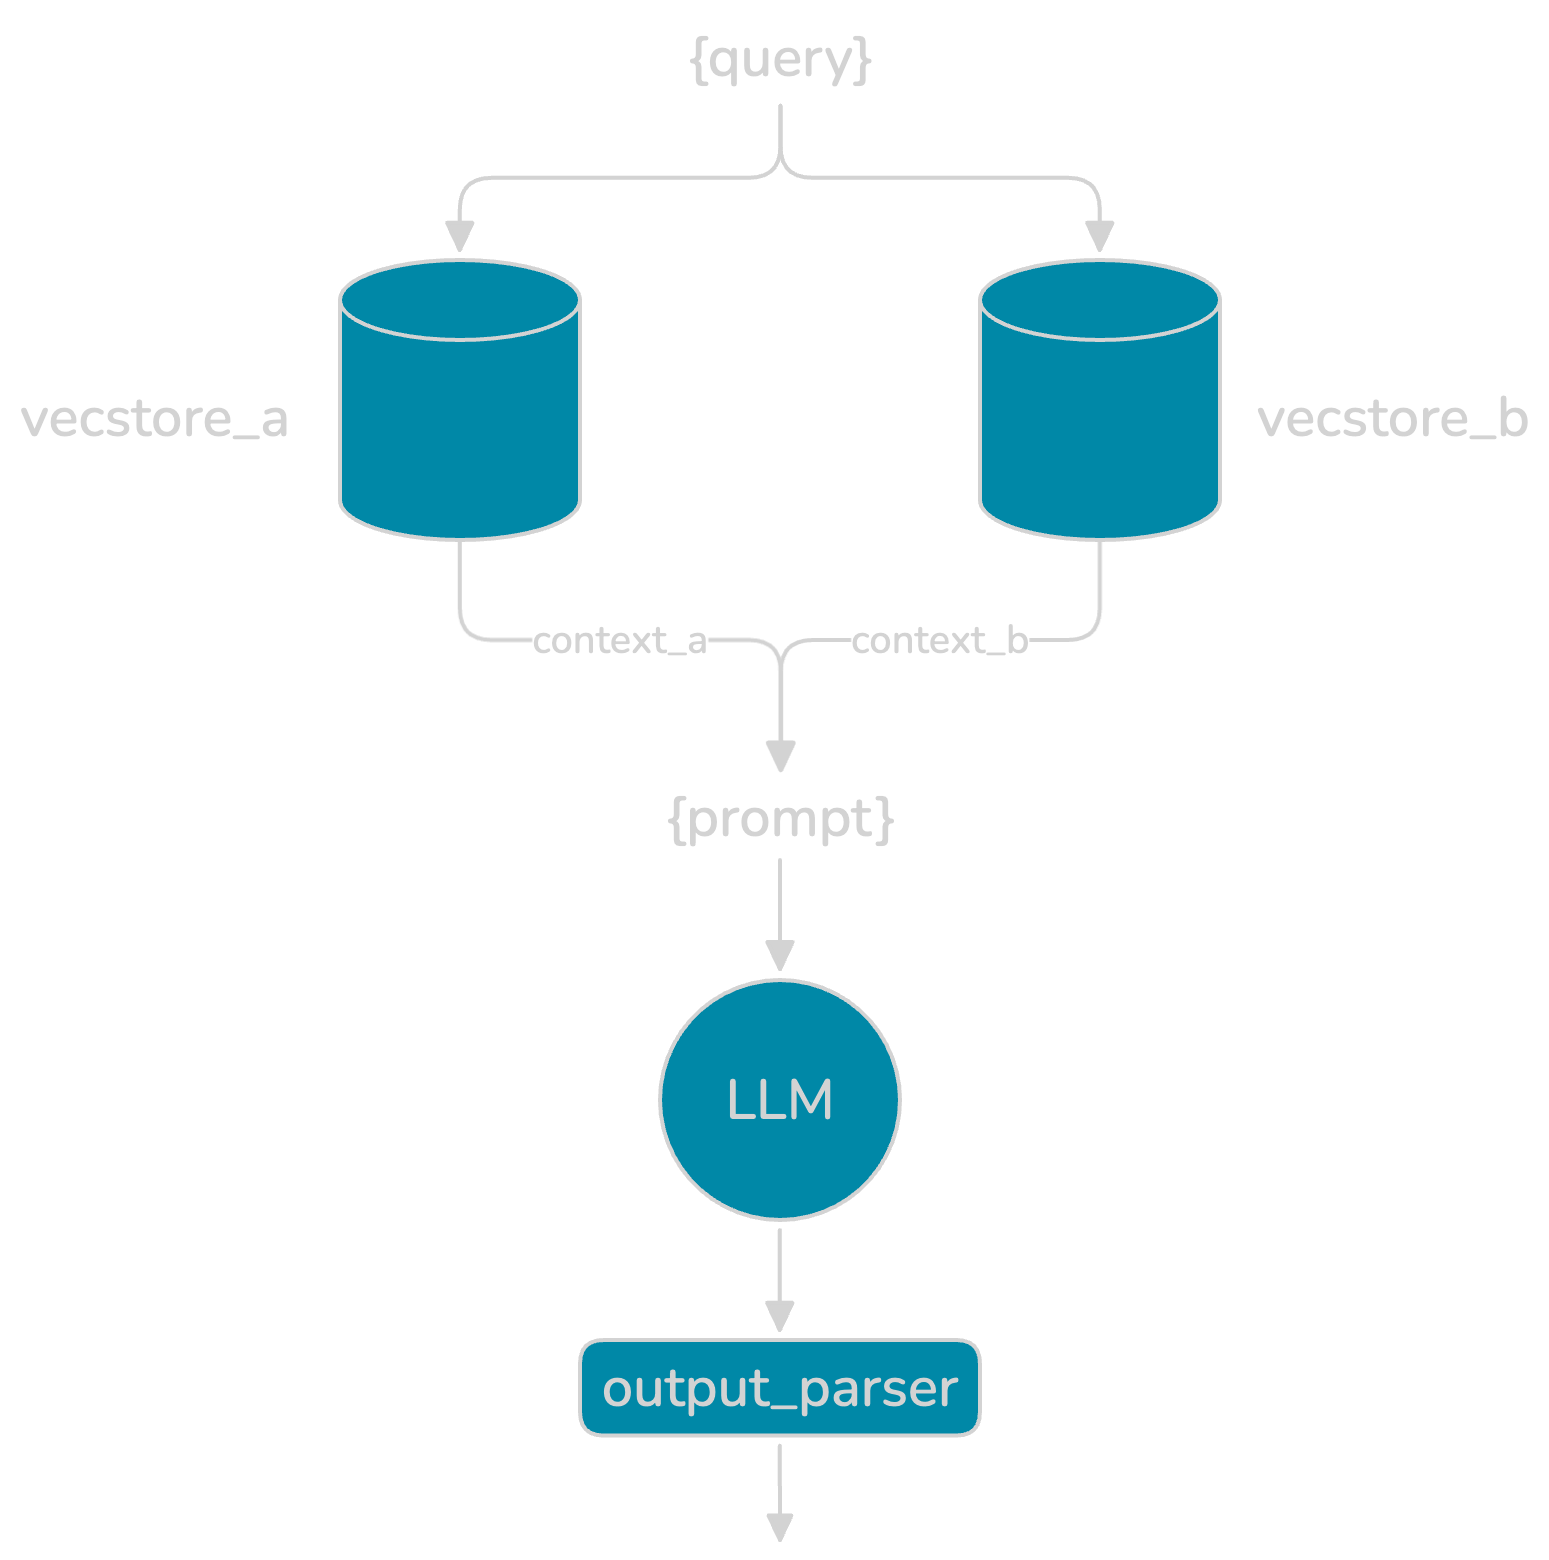

In [49]:
chain = retrieval | prompt | llm | output_parser

We invoke it as usual.

In [50]:
result = chain.invoke(
    "what architecture does the model DeepSeek released in december use?"
)
result

'The DeepSeek-V3 model uses a "mixture of experts" architecture.'